# MetaLore — Quick Demo

In [1]:
import sys
sys.path.insert(0, '.')

import matplotlib.pyplot as plt
import numpy as np
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv
from metalore.config import default_config
from metalore.config import ISAC_config
from metalore.config import small_config
from metalore.config import ISAC_cluster_config
print('MetaLore imported successfully!')

MetaLore imported successfully!


## Create & Reset Environment

In [2]:
config = ISAC_config()
N_STEPS =  100
config['environment']['max_steps'] = N_STEPS
env = SingleCellEnv(config=config)
obs, info = env.reset()

print(f'Base Stations : {env.num_bs}')
print(f'UEs           : {env.num_ues}')
print(f'Sensors       : {env.num_sensors}')
print(f'ISACs         : {env.num_isacs}')
print(f'Sensor placement: {env.config['sensor_placement']['mode']}')
print(f'Area          : {env.width} x {env.height} m')
print(f'Max Steps     : {env.EP_MAX_TIME}')
print(f'Action Space  : {env.action_space}')
print(f'Obs Space     : {env.observation_space}')
print(f'Initial obs   : {obs}')

Base Stations : 1
UEs           : 0
Sensors       : 8
ISACs         : 5
Sensor placement: uniform
Area          : 200.0 x 200.0 m
Max Steps     : 100
Action Space  : Box(0.0, 1.0, (7,), float32)
Obs Space     : Box(0.0, 10000.0, (3,), float32)
Initial obs   : [0. 0.]


## Run Episode with Rendering

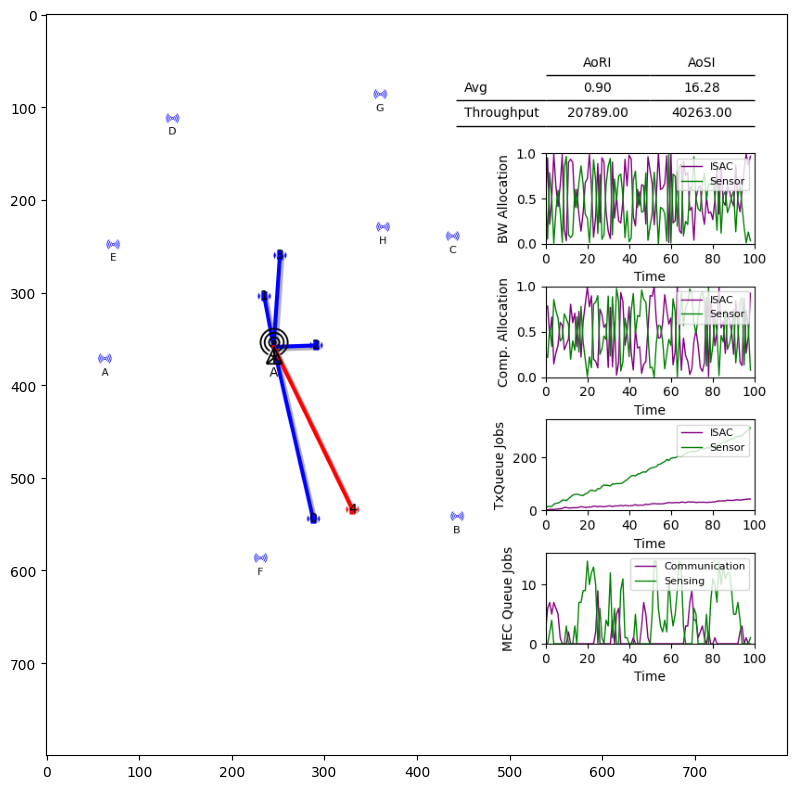

STEP: 99/100
TX QUEUES | UE: 0 | Sensors: 313 | ISAC: 42
MEC QUEUES| Communication (UE/ISAC): 0 | Sensing (Sensor/ISAC): 5
ISAC MODES: ['UE', 'SENSOR', 'UE', 'UE', 'UE']
Episode ended at step 100

Steps completed : 100
Total reward    : 710.0565


In [3]:
# Run a full episode with random actions
rewards = []
for step in range(N_STEPS):
    action = env.action_space.sample()   # random policy
    """ fixed_bw = 0.5
    fixed_comp = 0.5
    fixed_alpha = 1.0 #UE Mode
    action = np.array([fixed_bw, fixed_comp] + [fixed_alpha] * env.num_isacs, dtype=np.float32) """                # fixed equal-split policy
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    ue_tx_q = sum(ue.tx_queue.length for ue in env.active_ues)
    sensor_tx_q = sum(s.tx_queue.length for s in env.active_sensors)
    isac_tx_q = sum(isac.tx_queue.length for isac in env.active_isacs)

    bs_proc_ue = env.stations[0].proc_queues['UE'].length
    bs_proc_sensor = env.stations[0].proc_queues['SENSOR'].length

    print(f"STEP: {step}/{N_STEPS}")
    print(f"TX QUEUES | UE: {ue_tx_q} | Sensors: {sensor_tx_q} | ISAC: {isac_tx_q}")
    print(f"MEC QUEUES| Communication (UE/ISAC): {bs_proc_ue} | Sensing (Sensor/ISAC): {bs_proc_sensor}")
    
    if env.active_isacs:
        alphas = action[2:]
        env.config['isac']['communication_prob'] = 0.5
        modes = [isac.current_mode for isac in env.active_isacs]
        print(f"ISAC MODES: {modes}")
        
    if terminated or truncated:
        print(f"Episode ended at step {step+1}")
        break
    
    # Animate during simulation
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(env.render())
    plt.tight_layout()
    plt.show()
    plt.close()

print()
print(f"Steps completed : {len(rewards)}")
print(f"Total reward    : {sum(rewards):.4f}")

## Job Log (completed jobs)

In [4]:
import pandas as pd
from IPython.display import display

job_df = env.job_tracker.to_dataframe()
print(f'Completed jobs: {len(job_df)}')
display(job_df)

Completed jobs: 830


,job_id,entity_id,entity_type,job_type,data_size,compute_size,generated_at,tx_start_at,tx_end_at,proc_start_at,proc_end_at,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,nearest_sensor_id,sensor_snapshot_at,aoi,aori,aosi
0,7,7,SENSOR,SENSOR,55.0,6.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
1,0,0,SENSOR,SENSOR,83.0,3.0,0,0,2,2,2,0,2,0,0,NaN,NaN,NaN,2,NaN
2,1,1,SENSOR,SENSOR,64.0,6.0,0,0,2,2,2,0,2,0,0,NaN,NaN,NaN,2,NaN
3,2,2,SENSOR,SENSOR,85.0,8.0,0,0,2,2,2,0,2,0,0,NaN,NaN,NaN,2,NaN
4,3,3,SENSOR,SENSOR,72.0,2.0,0,0,2,2,2,0,2,0,0,NaN,NaN,NaN,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,1189,4,ISAC,UE,74.0,6.0,99,99,99,99,99,0,0,0,0,5.0,65.0,34.0,0,34.0
826,819,4,ISAC,SENSOR,71.0,12.0,68,89,98,98,99,21,9,0,1,NaN,NaN,NaN,31,NaN
827,736,0,SENSOR,SENSOR,75.0,6.0,62,94,99,99,99,32,5,0,0,NaN,NaN,NaN,37,NaN
828,643,1,SENSOR,SENSOR,75.0,8.0,54,94,99,99,99,40,5,0,0,NaN,NaN,NaN,45,NaN


## AoI Summary (UE jobs only)

In [5]:
ue_df = job_df[job_df['job_type'] == 'UE']

for col, label in [('aori', 'AoRI'), ('aosi', 'AoSI'), ('aoi', 'AoI')]:
    s = ue_df[col].dropna()
    if not s.empty:
        print(f'{label:5s}  mean={s.mean():.2f}  max={s.max():.0f}  min={s.min():.0f}')

AoRI   mean=0.89  max=9  min=0
AoSI   mean=16.46  max=42  min=0
AoI    mean=17.35  max=42  min=2
